In [ ]:
# ============================================================
# CELL 1: SETUP
# ============================================================
!pip install yfinance --quiet

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.facecolor'] = '#0F0F1A'
plt.rcParams['axes.facecolor'] = '#0F0F1A'
plt.rcParams['axes.labelcolor'] = '#AAAAAA'
plt.rcParams['xtick.color'] = '#AAAAAA'
plt.rcParams['ytick.color'] = '#AAAAAA'
plt.rcParams['text.color'] = 'white'
plt.rcParams['grid.color'] = '#333355'
plt.rcParams['grid.linewidth'] = 0.5

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [ ]:
# ============================================================
# CELL 2: UNIVERSE & DATA COLLECTION
# ============================================================

# Diversified ETF universe — equities, bonds, commodities, international
TICKERS = [
    'SPY',   # US Large Cap Equities
    'QQQ',   # US Tech/Growth
    'IWM',   # US Small Cap
    'EFA',   # International Developed Markets
    'EEM',   # Emerging Markets
    'AGG',   # US Bonds
    'GLD',   # Gold
    'USO',   # Oil
]

START_DATE = '2015-01-01'
END_DATE   = '2025-01-01'

print(f"Downloading price data for {len(TICKERS)} assets...")

raw = yf.download(TICKERS, start=START_DATE, end=END_DATE)['Close']
prices = raw.dropna(how='all').ffill()

# Daily log returns
returns = np.log(prices / prices.shift(1)).dropna()

print(f"Data loaded: {len(prices)} trading days ({START_DATE} to {END_DATE})")
print(f"Assets: {list(prices.columns)}")
prices.tail(3)

[*********************100%***********************]  8 of 8 completed


Data loaded: 2516 trading days (2015-01-01 to 2025-01-01)
Assets: ['AGG', 'EEM', 'EFA', 'GLD', 'IWM', 'QQQ', 'SPY', 'USO']


Ticker,AGG,EEM,EFA,GLD,IWM,QQQ,SPY,USO
Date,,,,,,,,
2024-12-27,91.412102,41.089504,72.338089,241.399994,219.005539,518.698425,584.994934,73.849998
2024-12-30,91.771538,40.759235,71.862877,240.630005,217.321548,511.799744,578.319214,74.820000
2024-12-31,91.658035,40.623238,71.862877,242.130005,217.597321,507.452118,576.215332,75.550003


In [ ]:
# ============================================================
# CELL 3: BACKTESTING ENGINE CORE
# Reusable framework — all strategies plug into this
# ============================================================

TRANSACTION_COST = 0.001  # 10bps per trade (one-way) — realistic for ETFs

def backtest(signal_df, returns_df, cost=TRANSACTION_COST, name='Strategy'):
    """
    Core backtesting engine. Takes a signal DataFrame and computes
    strategy returns with transaction costs applied.

    Args:
        signal_df  : DataFrame of position signals (values between -1 and 1)
                     Same shape as returns_df. Signals are applied next-day
                     (no lookahead bias).
        returns_df : DataFrame of daily log returns
        cost       : One-way transaction cost per unit of turnover
        name       : Strategy name for labelling

    Returns:
        Dictionary containing equity curve, daily returns, and metrics
    """
    # Align signal and returns on matching dates
    signal, rets = signal_df.align(returns_df, join='inner', axis=0)

    # Shift signals by 1 day to avoid lookahead bias
    # (signal generated on day T is executed on day T+1)
    signal_lagged = signal.shift(1).fillna(0)

    # Compute daily turnover (absolute change in position)
    turnover = signal_lagged.diff().abs().sum(axis=1)

    # Gross portfolio return = sum of (position * asset return) across assets
    gross_returns = (signal_lagged * rets).sum(axis=1)

    # Net return = gross return minus transaction costs
    net_returns = gross_returns - cost * turnover

    # Cumulative equity curve (starting at 1.0)
    equity_curve = (1 + net_returns).cumprod()

    return {
        'name': name,
        'daily_returns': net_returns,
        'equity_curve': equity_curve,
        'turnover': turnover,
        'signal': signal_lagged
    }


def compute_metrics(result):
    """
    Computes a full set of risk-adjusted performance metrics
    from a backtest result dictionary.
    """
    r = result['daily_returns']
    ann_factor = 252  # trading days per year

    # Annualised return and volatility
    ann_return = r.mean() * ann_factor
    ann_vol    = r.std() * np.sqrt(ann_factor)

    # Sharpe ratio (assume risk-free rate = 0)
    sharpe = ann_return / ann_vol if ann_vol > 0 else 0

    # Sortino ratio (uses downside deviation only)
    downside = r[r < 0].std() * np.sqrt(ann_factor)
    sortino = ann_return / downside if downside > 0 else 0

    # Maximum drawdown
    equity = result['equity_curve']
    rolling_max = equity.cummax()
    drawdown = (equity - rolling_max) / rolling_max
    max_dd = drawdown.min()

    # Calmar ratio (annualised return / max drawdown magnitude)
    calmar = ann_return / abs(max_dd) if max_dd != 0 else 0

    # Average daily turnover
    avg_turnover = result['turnover'].mean()

    return {
        'Strategy': result['name'],
        'Ann. Return': f"{ann_return:.2%}",
        'Ann. Volatility': f"{ann_vol:.2%}",
        'Sharpe Ratio': f"{sharpe:.2f}",
        'Sortino Ratio': f"{sortino:.2f}",
        'Calmar Ratio': f"{calmar:.2f}",
        'Max Drawdown': f"{max_dd:.2%}",
        'Avg Daily Turnover': f"{avg_turnover:.4f}"
    }

print("Backtesting engine loaded.")

Backtesting engine loaded.


In [ ]:
# ============================================================
# CELL 4: STRATEGY 1 — MOMENTUM
# 12-1 month cross-sectional momentum
# Buy top third of assets, sell bottom third, rebalance monthly
# ============================================================

def momentum_signal(prices, lookback=252, skip=21):
    """
    Computes cross-sectional momentum signal.

    For each asset, the momentum score is the return over the past
    'lookback' days, skipping the most recent 'skip' days.
    This avoids the short-term reversal effect documented in academic research.

    Assets are ranked cross-sectionally each month:
    - Top third  -> long  (+1)
    - Middle third -> neutral (0)
    - Bottom third -> short (-1)
    """
    # Momentum score = return from (lookback) days ago to (skip) days ago
    mom_score = prices.shift(skip) / prices.shift(lookback) - 1

    signal = pd.DataFrame(0.0, index=prices.index, columns=prices.columns)

    for date in prices.index:
        scores = mom_score.loc[date].dropna()
        if len(scores) < 3:
            continue
        n = len(scores)
        top_third    = scores.nlargest(n // 3).index
        bottom_third = scores.nsmallest(n // 3).index
        signal.loc[date, top_third]    =  1.0 / len(top_third)
        signal.loc[date, bottom_third] = -1.0 / len(bottom_third)

    # Resample to monthly — only rebalance once per month
    # (hold signal constant between rebalance dates)
    monthly_signal = signal.resample('ME').last()
    signal_monthly = monthly_signal.reindex(prices.index, method='ffill')

    return signal_monthly.fillna(0)

print("Computing Momentum signals (this may take 30-60 seconds)...")
mom_signal = momentum_signal(prices)
mom_result = backtest(mom_signal, returns, name='Momentum')
mom_metrics = compute_metrics(mom_result)
print(f"Momentum | Sharpe: {mom_metrics['Sharpe Ratio']} | Return: {mom_metrics['Ann. Return']} | MaxDD: {mom_metrics['Max Drawdown']}")

Computing Momentum signals (this may take 30-60 seconds)...
Momentum | Sharpe: 0.07 | Return: 1.56% | MaxDD: -49.72%


In [ ]:
# ============================================================
# CELL 5: STRATEGY 2 — MEAN REVERSION
# RSI + Bollinger Band signal
# Buy oversold assets, sell overbought assets
# ============================================================

def compute_rsi(prices, window=14):
    """
    Computes the Relative Strength Index (RSI) for each asset.
    RSI measures the speed and magnitude of recent price changes.
    RSI < 30 = oversold (potential buy), RSI > 70 = overbought (potential sell).
    """
    delta = prices.diff()
    gain  = delta.clip(lower=0)
    loss  = -delta.clip(upper=0)
    avg_gain = gain.rolling(window).mean()
    avg_loss = loss.rolling(window).mean()
    rs  = avg_gain / avg_loss.replace(0, np.nan)
    rsi = 100 - (100 / (1 + rs))
    return rsi


def mean_reversion_signal(prices, rsi_window=14, bb_window=20, bb_std=2.0):
    """
    Generates a mean-reversion signal combining RSI and Bollinger Bands.

    Buy signal  : RSI < 30 AND price below lower Bollinger Band
    Sell signal : RSI > 70 AND price above upper Bollinger Band
    Neutral     : all other conditions

    Positions are scaled by the distance from the band (stronger signal
    when price is further from the mean).
    """
    rsi = compute_rsi(prices, rsi_window)

    rolling_mean = prices.rolling(bb_window).mean()
    rolling_std  = prices.rolling(bb_window).std()
    upper_band   = rolling_mean + bb_std * rolling_std
    lower_band   = rolling_mean - bb_std * rolling_std

    signal = pd.DataFrame(0.0, index=prices.index, columns=prices.columns)

    # Long signal: oversold (RSI < 30) and below lower band
    long_mask  = (rsi < 30) & (prices < lower_band)
    # Short signal: overbought (RSI > 70) and above upper band
    short_mask = (rsi > 70) & (prices > upper_band)

    signal[long_mask]  =  1.0
    signal[short_mask] = -1.0

    # Normalise rows so total position sums to at most 1
    row_sum = signal.abs().sum(axis=1).replace(0, np.nan)
    signal  = signal.div(row_sum, axis=0).fillna(0)

    return signal

print("Computing Mean-Reversion signals...")
mr_signal = mean_reversion_signal(prices)
mr_result = backtest(mr_signal, returns, name='Mean-Reversion')
mr_metrics = compute_metrics(mr_result)
print(f"Mean-Reversion | Sharpe: {mr_metrics['Sharpe Ratio']} | Return: {mr_metrics['Ann. Return']} | MaxDD: {mr_metrics['Max Drawdown']}")

Computing Mean-Reversion signals...
Mean-Reversion | Sharpe: -0.70 | Return: -8.62% | MaxDD: -65.14%


In [ ]:
# ============================================================
# CELL 6: STRATEGY 3 — BREAKOUT (DONCHIAN CHANNEL)
# Go long on new highs, short on new lows
# Captures trending/momentum regimes
# ============================================================

def breakout_signal(prices, window=20):
    """
    Generates a Donchian Channel breakout signal.

    Donchian Channel: upper = rolling max over 'window' days
                      lower = rolling min over 'window' days

    Long signal  : today's price > yesterday's rolling high (new breakout)
    Short signal : today's price < yesterday's rolling low  (new breakdown)
    Neutral      : price within the channel

    Uses yesterday's channel to avoid lookahead bias.
    """
    upper = prices.rolling(window).max().shift(1)
    lower = prices.rolling(window).min().shift(1)

    signal = pd.DataFrame(0.0, index=prices.index, columns=prices.columns)

    long_mask  = prices > upper
    short_mask = prices < lower

    signal[long_mask]  =  1.0
    signal[short_mask] = -1.0

    # Normalise rows
    row_sum = signal.abs().sum(axis=1).replace(0, np.nan)
    signal  = signal.div(row_sum, axis=0).fillna(0)

    return signal

print("Computing Breakout signals...")
bo_signal = breakout_signal(prices)
bo_result = backtest(bo_signal, returns, name='Breakout')
bo_metrics = compute_metrics(bo_result)
print(f"Breakout | Sharpe: {bo_metrics['Sharpe Ratio']} | Return: {bo_metrics['Ann. Return']} | MaxDD: {bo_metrics['Max Drawdown']}")

Computing Breakout signals...
Breakout | Sharpe: -0.74 | Return: -14.43% | MaxDD: -80.66%


In [ ]:
# ============================================================
# CELL 7: ENSEMBLE PORTFOLIO
# Equal-weight combination of all three strategies
# ============================================================

def ensemble_signal(signal_list, weights=None):
    """
    Combines multiple strategy signals into a single ensemble signal.

    Default: equal-weight average of all signals.
    Each individual signal is already normalised, so the ensemble
    is a weighted blend of the three strategy views.
    """
    if weights is None:
        weights = [1.0 / len(signal_list)] * len(signal_list)

    ensemble = sum(w * s for w, s in zip(weights, signal_list))
    return ensemble

print("Computing Ensemble signals...")
ens_signal = ensemble_signal([mom_signal, mr_signal, bo_signal])
ens_result = backtest(ens_signal, returns, name='Ensemble')
ens_metrics = compute_metrics(ens_result)
print(f"Ensemble | Sharpe: {ens_metrics['Sharpe Ratio']} | Return: {ens_metrics['Ann. Return']} | MaxDD: {ens_metrics['Max Drawdown']}")

# Collect all results
all_results  = [mom_result, mr_result, bo_result, ens_result]
all_metrics  = [mom_metrics, mr_metrics, bo_metrics, ens_metrics]
metrics_df   = pd.DataFrame(all_metrics).set_index('Strategy')

print("\n=== PERFORMANCE SUMMARY ===")
print(metrics_df.to_string())

Computing Ensemble signals...
Ensemble | Sharpe: -0.52 | Return: -5.35% | MaxDD: -45.58%

=== PERFORMANCE SUMMARY ===
               Ann. Return Ann. Volatility Sharpe Ratio Sortino Ratio Calmar Ratio Max Drawdown Avg Daily Turnover
Strategy                                                                                                          
Momentum             1.56%          22.87%         0.07          0.09         0.03      -49.72%             0.0350
Mean-Reversion      -8.62%          12.35%        -0.70         -0.51        -0.13      -65.14%             0.3330
Breakout           -14.43%          19.38%        -0.74         -1.13        -0.18      -80.66%             0.9600
Ensemble            -5.35%          10.29%        -0.52         -0.82        -0.12      -45.58%             0.3706


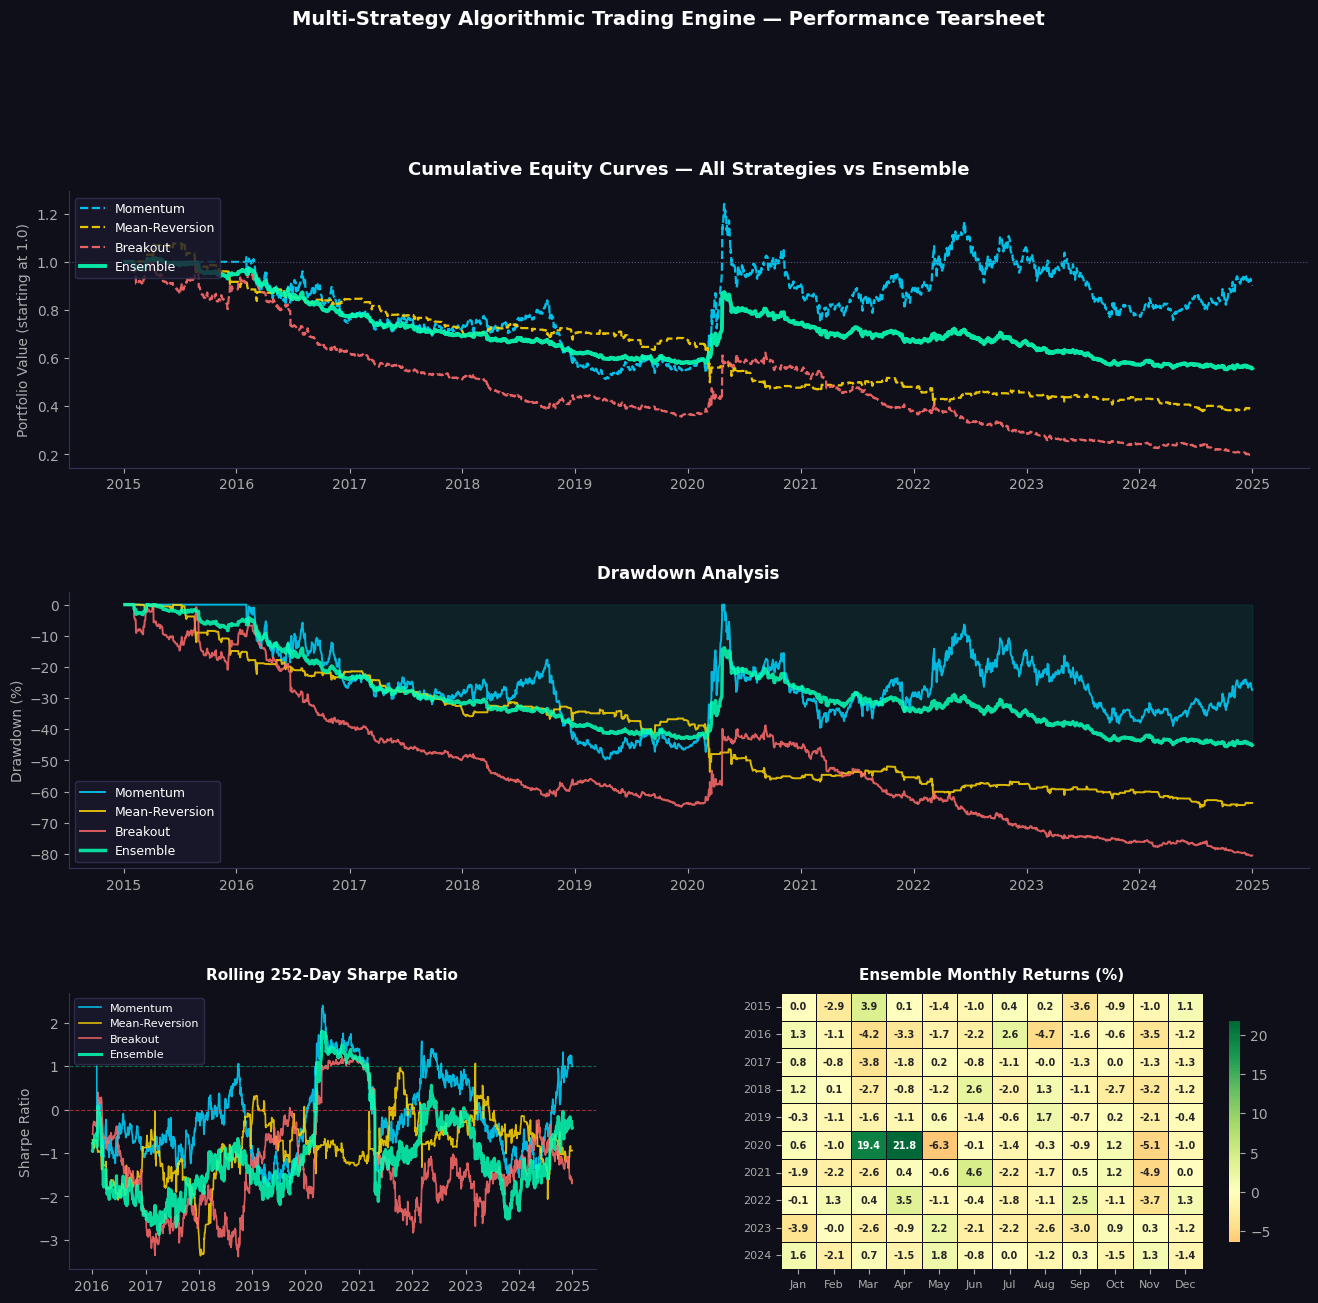

Tearsheet saved.


In [ ]:
# ============================================================
# CELL 8: TEARSHEET DASHBOARD (DISTINCTIVE STYLE)
# ============================================================

colors = {
    'Momentum':       '#00D4FF',
    'Mean-Reversion': '#FFD700',
    'Breakout':       '#FF6B6B',
    'Ensemble':       '#06FFB4',
}

fig = plt.figure(figsize=(16, 14), facecolor='#0F0F1A')
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)

# ── Chart 1: Cumulative equity curves ────────────────────────
ax1 = fig.add_subplot(gs[0, :])
ax1.set_facecolor('#0F0F1A')

for result in all_results:
    lw = 2.8 if result['name'] == 'Ensemble' else 1.6
    ls = '-'  if result['name'] == 'Ensemble' else '--'
    ax1.plot(result['equity_curve'].index,
             result['equity_curve'],
             label=result['name'],
             color=colors[result['name']],
             linewidth=lw,
             linestyle=ls,
             alpha=0.9)

ax1.axhline(1.0, color='#555577', linestyle=':', linewidth=0.8)
ax1.set_title('Cumulative Equity Curves — All Strategies vs Ensemble',
              fontsize=13, fontweight='bold', color='white', pad=12)
ax1.set_ylabel('Portfolio Value (starting at 1.0)', color='#AAAAAA')
ax1.legend(loc='upper left', fontsize=9,
           facecolor='#1A1A2E', edgecolor='#333355',
           labelcolor='white')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_color('#333355')
ax1.spines['bottom'].set_color('#333355')

# ── Chart 2: Drawdown chart ───────────────────────────────────
ax2 = fig.add_subplot(gs[1, :])
ax2.set_facecolor('#0F0F1A')

for result in all_results:
    equity      = result['equity_curve']
    rolling_max = equity.cummax()
    drawdown    = (equity - rolling_max) / rolling_max
    lw = 2.5 if result['name'] == 'Ensemble' else 1.4
    ax2.plot(drawdown.index, drawdown * 100,
             label=result['name'],
             color=colors[result['name']],
             linewidth=lw, alpha=0.85)

ax2.fill_between(ens_result['equity_curve'].index,
                 ((ens_result['equity_curve'] -
                   ens_result['equity_curve'].cummax()) /
                  ens_result['equity_curve'].cummax()) * 100,
                 0, alpha=0.08, color='#06FFB4')

ax2.set_title('Drawdown Analysis', fontsize=12,
              fontweight='bold', color='white', pad=10)
ax2.set_ylabel('Drawdown (%)', color='#AAAAAA')
ax2.legend(loc='lower left', fontsize=9,
           facecolor='#1A1A2E', edgecolor='#333355',
           labelcolor='white')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_color('#333355')
ax2.spines['bottom'].set_color('#333355')

# ── Chart 3: Rolling 252-day Sharpe ──────────────────────────
ax3 = fig.add_subplot(gs[2, 0])
ax3.set_facecolor('#0F0F1A')

for result in all_results:
    r = result['daily_returns']
    rolling_sharpe = (r.rolling(252).mean() /
                      r.rolling(252).std()) * np.sqrt(252)
    lw = 2.2 if result['name'] == 'Ensemble' else 1.2
    ax3.plot(rolling_sharpe.index, rolling_sharpe,
             label=result['name'],
             color=colors[result['name']],
             linewidth=lw, alpha=0.85)

ax3.axhline(0, color='#FF4444', linestyle='--', linewidth=0.8, alpha=0.6)
ax3.axhline(1, color='#00FF99', linestyle='--', linewidth=0.8, alpha=0.4)
ax3.set_title('Rolling 252-Day Sharpe Ratio',
              fontsize=11, fontweight='bold', color='white', pad=10)
ax3.set_ylabel('Sharpe Ratio', color='#AAAAAA')
ax3.legend(loc='upper left', fontsize=8,
           facecolor='#1A1A2E', edgecolor='#333355',
           labelcolor='white')
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
ax3.spines['left'].set_color('#333355')
ax3.spines['bottom'].set_color('#333355')

# ── Chart 4: Monthly returns heatmap (Ensemble) ──────────────
ax4 = fig.add_subplot(gs[2, 1])
ax4.set_facecolor('#0F0F1A')

ens_monthly = ens_result['daily_returns'].resample('ME').sum()
ens_monthly_df = ens_monthly.to_frame('returns')
ens_monthly_df['year']  = ens_monthly_df.index.year
ens_monthly_df['month'] = ens_monthly_df.index.month

pivot = ens_monthly_df.pivot(index='year', columns='month', values='returns')
pivot.columns = ['Jan','Feb','Mar','Apr','May','Jun',
                 'Jul','Aug','Sep','Oct','Nov','Dec']

sns.heatmap(pivot * 100,
            annot=True, fmt='.1f',
            cmap='RdYlGn', center=0,
            ax=ax4, linewidths=0.5,
            linecolor='#0F0F1A',
            annot_kws={'size': 7, 'weight': 'bold'},
            cbar_kws={'shrink': 0.8})

ax4.set_title('Ensemble Monthly Returns (%)',
              fontsize=11, fontweight='bold', color='white', pad=10)
ax4.tick_params(colors='#AAAAAA', labelsize=8)
ax4.set_xlabel('')
ax4.set_ylabel('')

plt.suptitle('Multi-Strategy Algorithmic Trading Engine — Performance Tearsheet',
             fontsize=14, fontweight='bold', color='white', y=1.01)

plt.savefig('strategy_tearsheet.png', dpi=150,
            bbox_inches='tight', facecolor='#0F0F1A')
plt.show()
print("Tearsheet saved.")

In [ ]:
# ============================================================
# CELL 9: PERFORMANCE SUMMARY REPORT
# ============================================================

print("=" * 75)
print("MULTI-STRATEGY TRADING ENGINE — PERFORMANCE REPORT")
print(f"Universe: {', '.join(TICKERS)}")
print(f"Period  : {START_DATE} to {END_DATE}")
print(f"Transaction Cost: {TRANSACTION_COST*100:.1f}bps per trade (one-way)")
print("=" * 75)
print(metrics_df.to_string())
print("=" * 75)
print("\nKey Concepts:")
print("  Sharpe Ratio  : Risk-adjusted return (higher = better, >1 is good)")
print("  Sortino Ratio : Like Sharpe but only penalises downside volatility")
print("  Calmar Ratio  : Annualised return divided by max drawdown")
print("  Max Drawdown  : Largest peak-to-trough decline in portfolio value")
print("  Turnover      : Average daily position change (higher = more trading costs)")

MULTI-STRATEGY TRADING ENGINE — PERFORMANCE REPORT
Universe: SPY, QQQ, IWM, EFA, EEM, AGG, GLD, USO
Period  : 2015-01-01 to 2025-01-01
Transaction Cost: 0.1bps per trade (one-way)
               Ann. Return Ann. Volatility Sharpe Ratio Sortino Ratio Calmar Ratio Max Drawdown Avg Daily Turnover
Strategy                                                                                                          
Momentum             1.56%          22.87%         0.07          0.09         0.03      -49.72%             0.0350
Mean-Reversion      -8.62%          12.35%        -0.70         -0.51        -0.13      -65.14%             0.3330
Breakout           -14.43%          19.38%        -0.74         -1.13        -0.18      -80.66%             0.9600
Ensemble            -5.35%          10.29%        -0.52         -0.82        -0.12      -45.58%             0.3706

Key Concepts:
  Sharpe Ratio  : Risk-adjusted return (higher = better, >1 is good)
  Sortino Ratio : Like Sharpe but only penalis

In [ ]:
# ============================================================
# CELL 10: SAVE OUTPUTS & GITHUB PREP
# ============================================================

metrics_df.to_csv('performance_summary.csv')

print("Files saved:")
print("  strategy_tearsheet.png   — Full performance tearsheet dashboard")
print("  performance_summary.csv  — Strategy metrics comparison table")
print()
print("Next steps:")
print("  1. Download files via the Colab file browser (folder icon, left sidebar)")
print("  2. File > Download > Download .ipynb to save the notebook")
print("  3. Rename notebook to Multi_Strategy_Trading_Engine.ipynb")
print("  4. Upload to GitHub repo: multi-strategy-trading-engine")
print("  5. Add to README: ![Tearsheet](strategy_tearsheet.png)")

Files saved:
  strategy_tearsheet.png   — Full performance tearsheet dashboard
  performance_summary.csv  — Strategy metrics comparison table

Next steps:
  1. Download files via the Colab file browser (folder icon, left sidebar)
  2. File > Download > Download .ipynb to save the notebook
  3. Rename notebook to Multi_Strategy_Trading_Engine.ipynb
  4. Upload to GitHub repo: multi-strategy-trading-engine
  5. Add to README: ![Tearsheet](strategy_tearsheet.png)
